# Παλινδρόμηση (Regression)

Σε αυτό το Notebook θα δούμε πάλι όλες τις ιδέες που έχουμε αναπτύξει με προβλήματα ταξινόμησης, αλλά στο πλαίσιο της **παλινδρόμησης**. Θυμόμαστε πως στην παλινδρόμηση τα **y** που θέλουμε να προβλέψουμε/εκτιμήσουμε είναι αριθμοί, ενώ στην ταξινόμηση εκτιμούμε την κλάση ή κατηγορία στην οποία ανήκει το δείγμα.  

Οπότε σε αυτό το Notebook έχουμε:

* Παλινδρόμηση: ένα απλό παράδειγμα
* Υπερμοντελοποίηση στην Παλινδρόμηση

```
Κωνσταντίνος Καραμανής: constantine@utexas.edu
http://users.ece.utexas.edu/~cmcaram/
The University of Texas at Austin
Archimedes/Athena RC
```

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


### Παραδείγματα Παλινδρόμησης

Στην παλινδρόμηση, από τα χαρακτηριστικά (features) $X$, θέλουμε να εκτιμίσουμε έναν αριθμό $y$. Κάποια παραδείγματα:
* Το $X$ είναι είκονα σώματος, και θέλουμε να εκτιμήσουμε την γωνία που σχηματίζει ο αγκώνας, $y$.

<img src="https://caramanis.github.io/images/ai_lectures/pose_estimation.png" width=200px/>

* Το $X$ είναι μία κριτική εστιατορίου (π.χ., google review), και το $y$ είναι εξιολόγηση του πόσο θετικό/αρνητικό είναι.

<img src="https://caramanis.github.io/images/ai_lectures/sentiment_detection.png" width=600px/>

* Το $X$ είναι είκονα προσώπου, και θέλουμε να εκτιμήσουμε την ηλικία, $y$.

<img src="https://caramanis.github.io/images/Caramanis_ECE_2018_06.jpg" width=100px/>


Σε αυτό το Notebook θα ασχοληθούμε με το πιο απλό παράδειγμα παλινδρόμησης: το $X$ και το $y$ είναι πραγματικοί αριθμοί, και θέλουμε να μάθουμε την σχέση μεταξύ τους.

(A) Τα δεδομένα: $(X,y)$.

<img src="https://caramanis.github.io/images/ai_lectures/regression1.png" width=300px/>

(B) Τα δεδομένα με την ευθεία που ορίζει την σχέση του $X$ με το $y$.

<img src="https://caramanis.github.io/images/ai_lectures/regression2.png" width=300px/>


### Δημιουργούμε τα δεδομένα

Για να δούμε την παλινδρόμηση στην πιο απλή της μορφή, θα δημιουργήσουμε εμείς δεδομένα συνθετικά -- δηλαδή, όχι πραγματικά. (Τα τεχνητά δεδομένα είναι χρήσιμα όταν θέλουμε να καταλάβουμε πως δουλεύει κάποιος αλγόριθμος).

Στο παράδειγμά μας, τα δεδομένα εισόδου $X$ (features) και εξόδου $y$ (labels), έχουν την εξής απλή σχέση:
```
y = 2 * X + 1 + θόρυβο
```

**Πληροφορία / Θόρυβος**: Όπως είδαμε και με το παράδειγμα της ταξινόμησης σε αυτό το Notebook, υπάρχει πραγματική πληροφορία, και υπάρχει και θόρυβος. Σε αυτό το παράδειγμα, η πληροφορία είναι η γραμμική σχέση ``y = 2 * X + 1``.

Ένα καλό μοντέλο θα μάθει αυτήν την σχέση από τα δεδομένα, $(x_1, y_1), (x_2,y_2),...,(x_n,y_n)$, και δεν θα προσπαθήσει να μοντελοποιήσει και τον θόρυβο.


In [2]:
np.random.seed(175)
n_samples = 20

# make the data: y = β_0 + β_1 x + noise
X = np.sort(np.random.rand(n_samples))
y = 2 * X + 1 + np.random.normal(0, 0.2, n_samples)
X = X.reshape(-1, 1)

### Απεικονίζουμε τα δεδομένα

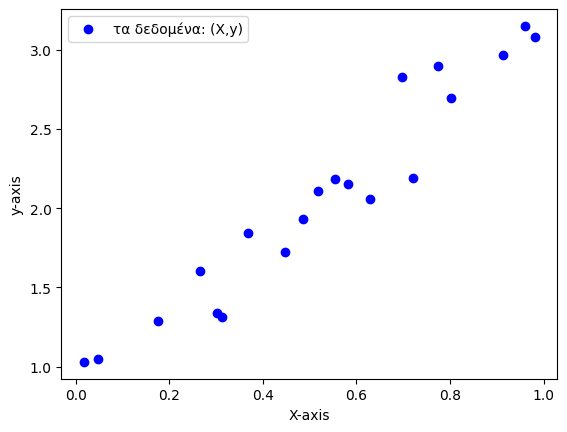

In [3]:
# Plot the original data
plt.scatter(X, y, color='blue', label='τα δεδομένα: (X,y)')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()


### Χωρίζουμε σε Train και Test

Όπως κάναμε και με το CIFAR-10, και τα προηούμενα παραδείγματα, χωρίζουμε τα δεδομένα μας σε δύο ομάδες: δεδομένα εκπαίδευσης (training data) και δεδομένα εκτίμησης (testing data).

Θα εκπαιδεύσουμε τον αλγόριθμό μας με τα πρώτα, και θα δούμε πόσο καλά τα πάει με τα δεύτερα.

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, shuffle=True, random_state=175)

## Διαλέγουμε και εκπαιδεύουμε ένα μοντέλο

Ακριβώς όπως κάναμε και με τα ρυχά δέντρα, και με το XGBoost, επιλέγουμε το μοντέλο της παλινδρόμησης (Linear Regression) και το εκπαιδεύουμε. Οι εντολές είναι παραπλήσιες - σχεδόν ολόιδιες - με αυτές που έχουμε ήδη δεί:
```
model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)
```

Η Παλινδρόμηση (Linear Regression) προσπαθεί να βρεί **μία γραμμική σχέση που συνδέει το $X$ και το $y$**.

In [5]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X)

### Το αποτέλεσμα
Ξαναβλέπουμε τα δεδομένα, τώρα μαζί με τις τιμές του $y$ που προβλέπει το μοντέλο μας.

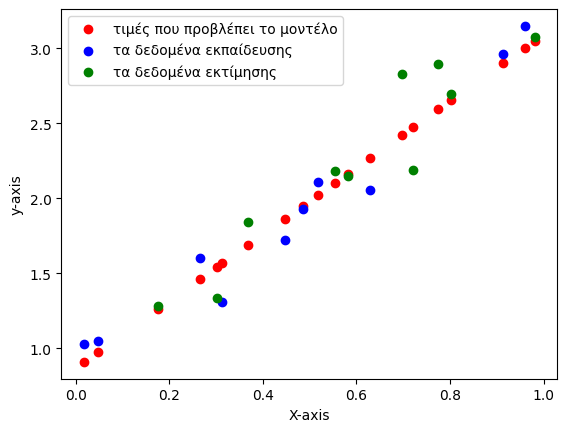

In [6]:
plt.scatter(X, y_pred, color='red', label='τιμές που προβλέπει το μοντέλο')
# Plot the original data
plt.scatter(X_train, y_train, color='blue', label='τα δεδομένα εκπαίδευσης')
plt.scatter(X_test, y_test, color='green', label='τα δεδομένα εκτίμησης')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()

### Μάθαμε την πραγματική σχέση

Βλέπουμε πως **τα κόκκινα σημεία δεν συμπίπτουν με τα μπλέ**. Στην προκειμένη περίπτωση, αυτό είναι καλό! Πράγματι, το μοντέλο μας έχει μάθει την σχέση μεταξύ $X$ και $y$, **αλλά δεν έχει προσπαθήσει να μάθει τον θόρυβο**!

Παρατηρούμε πως το μοντέλο που μάθαμε έχει περίπου την ίδια ακρίβεια στα δεδομένα εκπαίδευσης (μπλέ), και στα δεδομένα εκτίμησης (πράσινα). Θυμόμαστε από την συζήτηση στην ταξινόμηση (στο προηγούμενο Notebook) πως χαρακτηριστικό της υπερμοντελοίησης είναι όταν η ακρίβεια στα δεδομένα εκπαίδευσης είναι πολύ καλύτερη από την ακρίβεια στα δεδομένα εκτίμησης.

Μπορούμε να προσθέσουμε και την γραμμή που ενώνει τα κόκκινα σημεία, για να το δούμε αυτό πιο ξεκάθαρα.

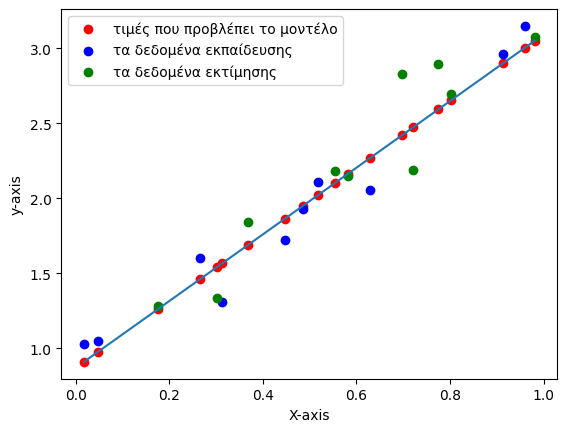

In [7]:
plt.plot(X, y_pred)
plt.scatter(X, y_pred, color='red', label='τιμές που προβλέπει το μοντέλο')
# Plot the original data
plt.scatter(X_train, y_train, color='blue', label='τα δεδομένα εκπαίδευσης')
plt.scatter(X_test, y_test, color='green', label='τα δεδομένα εκτίμησης')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()

## Δεύτερο Παράδειγμα

Όπως είδαμε πως μπορούμε να εκπαιδεύσουμε και πιο βαθιά δέντρα απόφασης, παρομοίως, μπορούμε αντί να βρούμε την  ευθεία γραμμή που ταιριάζει με τα δεδομένα μας, μπορούμε να βρούμε την καλύτερη καμπύλη με μορφή $k$-βαθμού πολυωνύμου.

Για το παράδειγμά μας, θα διαλέξουμε μεγάλο $k$: $k = 10$.

Δεν θα μπούμε σε λεπτομέριες εδώ. Αρκεί να πούμε πως χρειαζόμαστε 2 βήματα:
* Στο πρώτο, δημιοιυργούμε ένα νέο σετ δεδομένων, $X_{\rm poly}$ που περιέχει το $X^1$, $X^2$, ..., $X^k$.
* Στο δεύτερο βήμα, χρησιμοποιούμε πάλι το LinearRegression ακριβώς όπως κάναμε και παραπάνω, αλλά τώρα με τα διαμορφωμένα δεδομένα:
```
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_poly, y)
y_pred_poly = poly_reg_model.predict(X_poly)
```


In [8]:
# degree of polynomial
k = 10

# πρώτο βήμα
poly_features = PolynomialFeatures(degree=k)
X_poly = poly_features.fit_transform(X) # όλα τα δεδομένα
X_poly_train = poly_features.fit_transform(X_train) # δεδομένα εκπαίδευσης
X_poly_test = poly_features.fit_transform(X_test) # δεδομένα εκτίμησης


# δεύτερο βήμα
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_poly_train, y_train) # εκπαιδεύουμε μόνο στα X_train
y_pred_poly_train = poly_reg_model.predict(X_poly_train) # προβλέψεις του μοντέλου στα X_train
y_pred_poly = poly_reg_model.predict(X_poly) # προβλέψεις του μοντέλου σε όλα τα Χ

### Τα αποτελέσματα

Δεν βλέπουμε κάν τα κόκκινα σημεία. Γιατί; Διότι τα σημεία ``y_pred`` συμπίπτουν ακριβώς με τα σημεία ``y``.

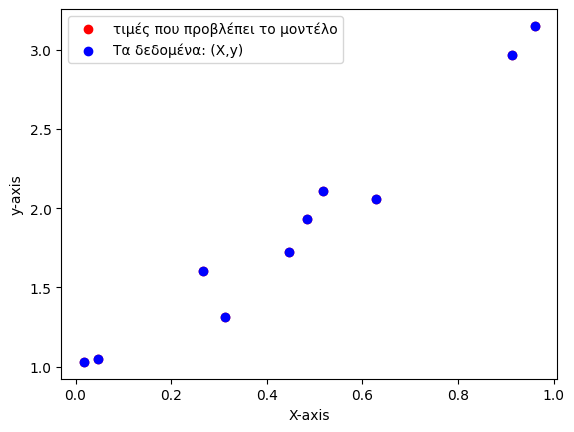

In [9]:
plt.scatter(X_train, y_pred_poly_train, color='red', label='τιμές που προβλέπει το μοντέλο')
# Plot the original data
plt.scatter(X_train, y_train, color='blue', label='Τα δεδομένα: (X,y)')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()

### Τα αποτελέσματα -- ξανά

Ας τα δούμε πιο προσεκτικά. Τι προβλέπει το μοντέλο μας για όλα τα άλλα πιθανά σημεία $X$; Στο προηγούμενο παράδειγμα, το μοντέλο μας προβλέπει σημεία που ακολουθούν την ευθεία γραμμή. Εδώ τι θα κάνει το μοντέλο μας;

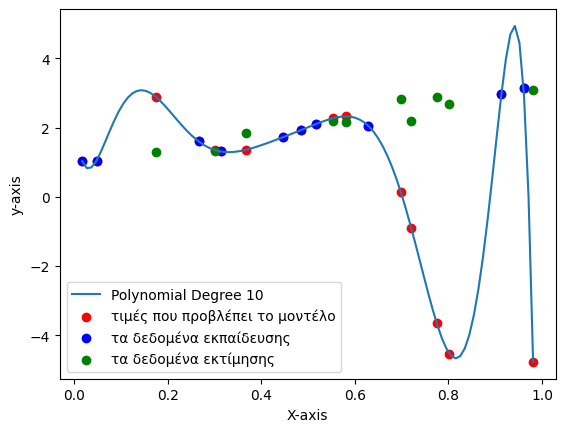

In [10]:
# Generate a finer grid of points
X_fine = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_fine_poly = poly_features.fit_transform(X_fine.reshape(-1, 1))
y_fine_pred = poly_reg_model.predict(X_fine_poly)

plt.plot(X_fine, y_fine_pred, label=f'Polynomial Degree {k}')

plt.scatter(X, y_pred_poly, color='red', label='τιμές που προβλέπει το μοντέλο')
plt.scatter(X_train, y_train, color='blue', label='τα δεδομένα εκπαίδευσης')
plt.scatter(X_test, y_test, color='green', label='τα δεδομένα εκτίμησης')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()

### Μας αρέσει το αποτέλεσμα;

Βλέπουμε πως το πιο ισχυρό μοντέλο που χρησιμοποιεί καμπύλες που τις ορίζει πολυώνυμο 10ου βαθμού, δεν καταφέρνει να βρεί την σωστή (γραμμική) σχέση μεταξύ του $X$ και του $y$.

**Το μοντέλο αυτό προσπαθεί να μοντελοποιήσει τον θόρυβο**. Δηλαδή, έχει υπερμοντελοποιήσει.

Αυτό φαίνεται ξεκάθαρα από τα δεδομένα εκτίμησης, δηλαδή τα πράσινα σημεία. Παρατηρείστε πως τα πράσινα σημεία (δεδομένα εκτίμησης) απέχουν πολύ από τα κόκκινα σημεία, που είναι η πρόβλεψη του μοντέλου μας. Σε αντίθεση, τα μπλέ σημεία (δεδομένα εκπαίδευσης) συμπίπτουν ακριβώς με τα την πρόβλεψη του μοντέλου (τόσο που η κόκκινη τελίτσα δεν φαίνεται κάν).

**Άσκηση**: μπορείτε να επαναλάβετε το πείραμε με άλλο random seed, για να δείτε πως το ίδιο φαινόμενο ισχύει.

## Τρίτο Παράδειγμα

Τώρα βλέπουμε ένα παράδειγμα όπου πράγματι τα δεδομένα μας έχουν μη-γραμμική σχέση. Σε αυτό το παράδειγμα, λοιπόν, εάν χρησιμοποιήσουμε γραμμικό μοντέλο, δεν θα βρούμε την σχέση μεταξύ $X$ και $y$. Αυτό λέγετε **υπομοντελοποίηση**, ή **underfitting**.

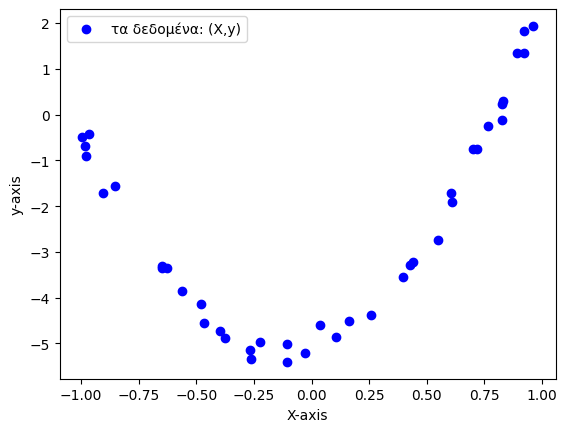

In [11]:
np.random.seed(175)
n_samples = 40

# make the data: y = β_0 + β_1 x + noise
X = np.sort(np.random.rand(n_samples)-0.5)*2
#y = 1.5*X + -3*X**2 + 5*X**3 -5 + np.random.normal(0, 0.2, n_samples)
y = 1.5*X + 6*X**2 + 0*X**3 -5 + np.random.normal(0, 0.2, n_samples)
X = X.reshape(-1, 1)

# Plot the original data
plt.scatter(X, y, color='blue', label='τα δεδομένα: (X,y)')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=175)

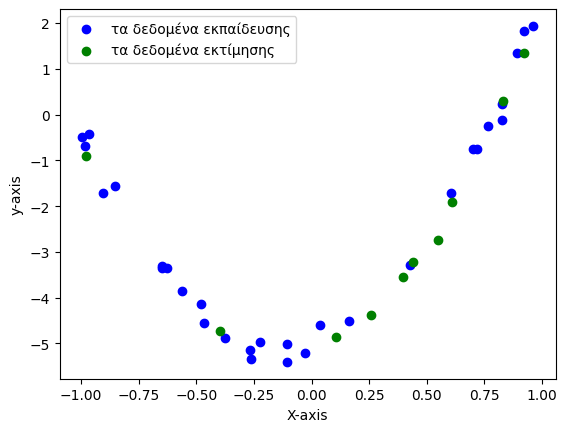

In [13]:
# Plot the training data
# Plot the original data
plt.scatter(X_train, y_train, color='blue', label='τα δεδομένα εκπαίδευσης')
plt.scatter(X_test, y_test, color='green', label='τα δεδομένα εκτίμησης')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()

### Ένα Γραμμικό Μοντέλο

Αρχίζουμε με ένα γραμμικό μοντέλο. Χρησιμοποιούμε ακριβώς τον ίδιο κώδικα που είδαμε παραπάνω:
```
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X)
```

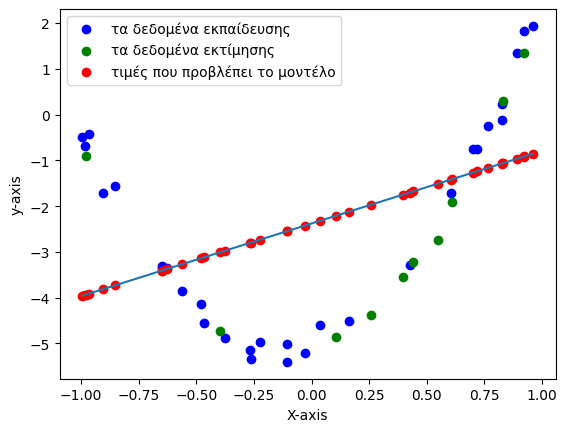

In [14]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X)

# plot the results
plt.plot(X, y_pred)
plt.scatter(X_train, y_train, color='blue', label='τα δεδομένα εκπαίδευσης')
plt.scatter(X_test, y_test, color='green', label='τα δεδομένα εκτίμησης')
plt.scatter(X, y_pred, color='red', label='τιμές που προβλέπει το μοντέλο')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()


### Υπομοντελοποίηση

Εμφανώς, η ευθεία γραμμή δεν ταιριάζει καλά με τα δεδομένα μας. Παρόλο αυτά, αφού χρησιμοποιήσαμε την εντολή ``model.fit(X_train,y_train)`` ξέρουμε πως από όλες τις ευθείες γραμμές, η απεικονιζόμενη είναι πράγματι αυτή που ταιριάζει καλύτερα με τα δεδομένα εκπαίδευσης.

Αυτό σημαίνει πως καμία ευθεία γραμμή δεν ταιριάζει καλά. Πρέπει να χρησιμοποιήσουμε μοντέλο με μεγαλύτερη εκφραστική δυνατότητα -- δηλαδή, ένα πιο περίπλοκο μοντέλο, διότι η οικογένεια των ευθείων γραμμών **υπομοντελοποιεί** (underfits) τα δεδομένα μας.

Θα δοκιμάσουμε καμπύλη που ορίζεται από πολυώνυμο δευτέρου βαθμού. Χρησιμοποιούμε ακριβώς τον ίδιο κώδικα που είχαμε και πρίν:

* Στο πρώτο βήμα, δημιοιυργούμε ένα νέο σετ δεδομένων, $X_{\rm poly}$ που περιέχει το $X$, και το $X^2$.
* Στο δεύτερο βήμα, χρησιμοποιούμε πάλι το LinearRegression ακριβώς όπως κάναμε και παραπάνω, αλλά τώρα με τα διαμορφωμένα δεδομένα:
```
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_poly, y)
y_pred_poly = poly_reg_model.predict(X_poly)
```


In [15]:
# degree of polynomial
k = 2
poly_features = PolynomialFeatures(degree=k)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.fit_transform(X_test)
X_poly = poly_features.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Τα αποτελέσματα

Απεικονίζουμε τα αποτελέσματα. Παρατηρούμε πως:

* Τα κόκκινα σημεία (οι τιμές που προβλέπει το μοντέλο μας) ταιριάζουν καλά με τα δεδομένα, οπότε δεν υπομοντελοποιούμε.
* Επίσης, τα κόκκινα σημεία ταιριάζουν εξίσου καλά με τα μπλέ (δεδομένα εκπαίδευσης) και τα πράσινα (δεδομένα εκτίμησης). Οπότε δεν υπερμοντελοποιούμε.

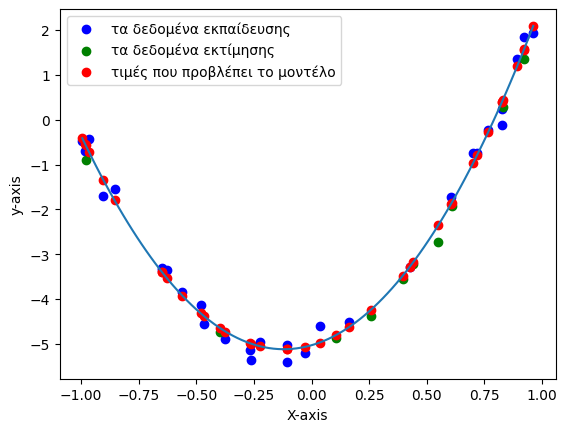

In [16]:
# Generate a finer grid of points
X_fine = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_fine_poly = poly_features.fit_transform(X_fine)
y_fine_pred = poly_model.predict(X_fine_poly)

plt.plot(X_fine, y_fine_pred)
y_pred = poly_model.predict(X_poly)

#plt.plot(X_test, y_pred)
plt.scatter(X_train, y_train, color='blue', label='τα δεδομένα εκπαίδευσης')
plt.scatter(X_test, y_test, color='green', label='τα δεδομένα εκτίμησης')
plt.scatter(X, y_pred, color='red', label='τιμές που προβλέπει το μοντέλο')

# Add labels to the axes
plt.xlabel('X-axis')
plt.ylabel('y-axis')

# Add a legend
plt.legend()

# Display the plot
plt.show()


# Εάν δεν ξέραμε ήδη την απάντηση;

Εύλογη παρατήρηση: στην προκειμένη περίπτωση, ξέραμε εκ των προτέρων πως η σχέση μεταξύ $X$ και $y$ ορίζεται από ένα πολυώνυμο δευτέρου βαθμού. **Εάν δεν ξέραμε**, τι θα κάναμε;

1. Χωρίζουμε τα δεδομένα (Χ,y) σε X_train, y_train, και X_test, y_test
2. Κάνουμε poly fit με degree κ, κ=1,...,degree_max
3. Βλέπουμε το training_error και testing_error
4. Διαλέγουμε το degree με το ελάχιστο testing_error

## **Άσκηση**:

Προσπαθήστε να συμπληρώσετε τα 4 βήματα.

Παρακάτω θα βρείτε τον κώδικα που υλοποιεί αυτά τα τέσσερα βήματα. Εάν θέλετε, μπορείτε να προσπαθήσετε να το κάνετε μόνοι σας, χωρίς να δείτε τον κώδικα. (Δίνουμε εμείς τον ολοκληρωμένο κώδικα λίγο πιο κάτω).

Στο τρίτο βήμα, θα χρειαστεί να υπολογίσετε το training_error και testing_error, δηλαδή την ανακρίβεια ή το σφάλμα του κάθε μοντέλου πάνω στα δεδομένα εκπαίδευσης και εκτίμησης.

Μπορείτε να χρησιμοποιήσετε την εντολή:
```
mean_squared_error(y,y_pred)
```
για να υπολογίσετε το σφάλμα (μέσο τετραγωνικό σφάλμα) μεταξύ του $y$, και του $y_{\rm pred}$.

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

### Ο Κώδικας

In [17]:
best_degree = 0
best_error = 10000
test_errors = []
train_errors = []
for degree in range(10):
  poly_features = PolynomialFeatures(degree=degree+1)
  X_poly_train = poly_features.fit_transform(X_train)
  X_poly_test = poly_features.fit_transform(X_test)
  poly_model = LinearRegression()
  poly_model.fit(X_poly_train, y_train)
  y_pred_train = poly_model.predict(X_poly_train)
  y_pred_test = poly_model.predict(X_poly_test)
  train_error = mean_squared_error(y_train, y_pred_train)
  test_error = mean_squared_error(y_test, y_pred_test)
  train_errors.append(train_error)
  test_errors.append(test_error)
  if test_error < best_error:
    best_degree = degree+1
    best_error = test_error

print(f'Best degree is {best_degree}')

Best degree is 2


### Ακρίβεια/σφάλμα εκπαίδευσης και εκτίμησης

Χρησιμοποιώντας την Pandas, μπορούμε να οργανώσουμε τα αποτελέσματα ώστε να πάρουμε μια συνολική εικόνα.

* Όσο αυξάνουμε τον βαθμό του πολυωνύμου, συνεχίζει να πέφτει το σφάλμα εκτίμησης στα δεδομένα εκπαίδευσης.
* Το ίδιο δεν ισχύει για τα δεδομένα εκπαίδευσης. Τα λάθη αυξάνονται από 3ου βαθμού και πάνω, διότι υπερμοντελοποιούμε.

In [18]:
import pandas as pd
# Create a DataFrame
data = {
    "Poly Degree": range(1,11),
    "Train Error": train_errors,
    "Test Error": test_errors,
}

df = pd.DataFrame(data)

# Display the table
print(df.to_string(index=False))

 Poly Degree  Train Error  Test Error
           1     4.269256    3.934970
           2     0.045177    0.035300
           3     0.044824    0.040877
           4     0.043745    0.042521
           5     0.039902    0.059151
           6     0.039621    0.067575
           7     0.038645    0.068498
           8     0.037690    0.056630
           9     0.037683    0.057208
          10     0.033833    0.069012
